# Fraud Detection - Load All Saved Models with gdown and Predict on Test Batches

This notebook does **not train models again**.

It downloads all saved backend-ready models from Google Drive using `gdown`, loads the same preprocessing artifacts, runs predictions for **all models**, compares the results, tests batches, checks Top-K fraud capture, and gives a simple train-vs-test overfitting warning.

You only need to replace the Google Drive file IDs in section 2.

## 1. Install and Import Libraries

In [ ]:
!pip install -q gdown kagglehub xgboost lightgbm catboost joblib

import os
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gdown
import kagglehub

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    precision_recall_curve,
    roc_curve,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

LABELS = ['Legitimate', 'Fraud']

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00


## 2. Configure gdown File IDs for All Models

Replace every `PUT_..._FILE_ID_HERE` with the real Google Drive file ID.

In Google Drive, each file must be shared as:

`Anyone with the link` → `Viewer`

You need:

- one preprocessing file: `preprocessing_artifacts.joblib`
- one optional backend config file: `backend_model_config.json`
- all model files you want to test

You can leave a model ID empty or as `PUT_...` and the notebook will skip it.

In [ ]:
GDOWN_FILE_IDS = {
    'preprocessing': '1WwV-ph2oQgNIGkuyaorNdrIqpM9b4t6Q',
    'backend_config': '1OD6LpeW8hBGrMCTkmsZAotetHwsesxMf',
    'models': {
        'Random Forest': '1hluJchjw8BtxfwE14p0smZUSCwXsBgsc',
        'XGBoost': '1MRtLHhd6eYMb2qgt6JV0ktQI-KksWbCg',
        'LightGBM': '1ZILKj91YAWG-ZB1qeTgA9HchdIBIqIq6',
        'CatBoost': '1bPFYEXV69iHb7QnP13X0JLMAjCyFgQc_',
        'Isolation Forest': '10BMBcmXs8Vz0c2_lbls3TLUITlOnbSPx',
    }
}

# Default thresholds. If you do not have special tuned thresholds, keep 0.5 for supervised models.
# Isolation Forest can use 0.0 because its anomaly score is based on -decision_function.
MODEL_THRESHOLDS = {
    'Random Forest': 0.5,
    'XGBoost': 0.5,
    'LightGBM': 0.5,
    'CatBoost': 0.5,
    'Isolation Forest': 0.0,
}

DOWNLOAD_DIR = '/content/fraud_all_models_downloaded'
MODELS_DIR = os.path.join(DOWNLOAD_DIR, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

PREPROCESSING_PATH = os.path.join(DOWNLOAD_DIR, 'preprocessing_artifacts.joblib')
BACKEND_CONFIG_PATH = os.path.join(DOWNLOAD_DIR, 'backend_model_config.json')

print('Download folder:', DOWNLOAD_DIR)
print('Models folder:', MODELS_DIR)

Download folder: /content/fraud_all_models_downloaded
Models folder: /content/fraud_all_models_downloaded/models


## 3. Download All Backend Artifacts from Google Drive

In [ ]:
def is_valid_file_id(file_id):
    return isinstance(file_id, str) and file_id.strip() and not file_id.startswith('PUT_')


def download_from_drive(file_id, output_path):
    if not is_valid_file_id(file_id):
        print(f'Skipping {output_path}: file ID was not set.')
        return False

    url = f'https://drive.google.com/uc?id={file_id}'
    gdown.download(url, output_path, quiet=False)
    return os.path.exists(output_path)


preprocessing_downloaded = download_from_drive(GDOWN_FILE_IDS['preprocessing'], PREPROCESSING_PATH)
config_downloaded = download_from_drive(GDOWN_FILE_IDS.get('backend_config'), BACKEND_CONFIG_PATH)

model_paths = {}
for model_name, file_id in GDOWN_FILE_IDS['models'].items():
    safe_name = model_name.lower().replace(' ', '_').replace('-', '_')
    output_path = os.path.join(MODELS_DIR, f'{safe_name}.joblib')
    downloaded = download_from_drive(file_id, output_path)
    if downloaded:
        model_paths[model_name] = output_path

print('Downloaded preprocessing:', preprocessing_downloaded, PREPROCESSING_PATH)
print('Downloaded backend config:', config_downloaded, BACKEND_CONFIG_PATH)
print('Downloaded models:')
for name, path in model_paths.items():
    print('-', name, '->', path)

if not preprocessing_downloaded:
    raise FileNotFoundError('preprocessing_artifacts.joblib was not downloaded. Add the correct file ID in section 2.')

if len(model_paths) == 0:
    raise FileNotFoundError('No models were downloaded. Add at least one real model file ID in section 2.')

Downloading...
From: https://drive.google.com/uc?id=1WwV-ph2oQgNIGkuyaorNdrIqpM9b4t6Q
To: /content/fraud_all_models_downloaded/preprocessing_artifacts.joblib
100%|██████████| 33.3k/33.3k [00:00<00:00, 49.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1OD6LpeW8hBGrMCTkmsZAotetHwsesxMf
To: /content/fraud_all_models_downloaded/backend_model_config.json
100%|██████████| 287/287 [00:00<00:00, 961kB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1hluJchjw8BtxfwE14p0smZUSCwXsBgsc
From (redirected): https://drive.google.com/uc?id=1hluJchjw8BtxfwE14p0smZUSCwXsBgsc&confirm=t&uuid=4f7b76e1-c2c7-4b25-a5b3-5eb07930777b
To: /content/fraud_all_models_downloaded/models/random_forest.joblib
100%|██████████| 125M/125M [00:01<00:00, 93.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1MRtLHhd6eYMb2qgt6JV0ktQI-KksWbCg
To: /content/fraud_all_models_downloaded/models/xgboost.joblib
100%|██████████| 1.48M/1.48M [00:00<00:00, 82.3MB/s]
Downloading...
From: https://driv

Downloaded preprocessing: True /content/fraud_all_models_downloaded/preprocessing_artifacts.joblib
Downloaded backend config: True /content/fraud_all_models_downloaded/backend_model_config.json
Downloaded models:
- Random Forest -> /content/fraud_all_models_downloaded/models/random_forest.joblib
- XGBoost -> /content/fraud_all_models_downloaded/models/xgboost.joblib
- LightGBM -> /content/fraud_all_models_downloaded/models/lightgbm.joblib
- CatBoost -> /content/fraud_all_models_downloaded/models/catboost.joblib
- Isolation Forest -> /content/fraud_all_models_downloaded/models/isolation_forest.joblib


## 4. Load Preprocessing and All Models

In [ ]:
preprocessing_artifacts = joblib.load(PREPROCESSING_PATH)

encoder = preprocessing_artifacts['encoder']
medians = preprocessing_artifacts['medians']
feature_columns = preprocessing_artifacts['feature_columns']
categorical_columns = preprocessing_artifacts['categorical_columns']

loaded_models = {}
for model_name, path in model_paths.items():
    loaded_models[model_name] = joblib.load(path)

if os.path.exists(BACKEND_CONFIG_PATH):
    with open(BACKEND_CONFIG_PATH, 'r') as f:
        backend_config = json.load(f)
    print('Backend config loaded:')
    print(json.dumps(backend_config, indent=4))
else:
    backend_config = {}
    print('No backend config found. Using MODEL_THRESHOLDS dictionary.')

print('Loaded models:')
for model_name, model in loaded_models.items():
    print('-', model_name, type(model))

print('Expected number of features:', len(feature_columns))
print('Categorical columns:', categorical_columns)

Backend config loaded:
{
    "best_model_name": "LightGBM",
    "best_model_file": "lightgbm.joblib",
    "best_threshold_by_f1": 0.9400000000000001,
    "preprocessing_file": "preprocessing_artifacts.joblib",
    "feature_columns_file": "feature_columns.json",
    "created_at": "2026-05-30T08:49:58.688304"
}
Loaded models:
- Random Forest <class 'sklearn.ensemble._forest.RandomForestClassifier'>
- XGBoost <class 'xgboost.sklearn.XGBClassifier'>
- LightGBM <class 'lightgbm.sklearn.LGBMClassifier'>
- CatBoost <class 'catboost.core.CatBoostClassifier'>
- Isolation Forest <class 'sklearn.ensemble._iforest.IsolationForest'>
Expected number of features: 16
Categorical columns: ['merchant', 'category', 'gender', 'job']


## 5. Load Kaggle Train/Test Data

In [ ]:
path = kagglehub.dataset_download('kartik2112/fraud-detection')
print('Dataset path:', path)

train_path = os.path.join(path, 'fraudTrain.csv')
test_path = os.path.join(path, 'fraudTest.csv')

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)
print('Fraud rate in train: {:.4f}%'.format(train_df['is_fraud'].mean() * 100))
print('Fraud rate in test:  {:.4f}%'.format(test_df['is_fraud'].mean() * 100))

Using Colab cache for faster access to the 'fraud-detection' dataset.
Dataset path: /kaggle/input/fraud-detection
Train shape: (1296675, 23)
Test shape: (555719, 23)
Fraud rate in train: 0.5789%
Fraud rate in test:  0.3860%


## 6. Same Feature Engineering Used During Training

In [ ]:
def haversine_distance(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c


def add_features(df):
    df = df.copy()
    df = df.drop(columns=[col for col in ['Unnamed: 0'] if col in df.columns], errors='ignore')

    if 'trans_date_trans_time' in df.columns:
        trans_time = pd.to_datetime(df['trans_date_trans_time'], errors='coerce')
        df['hour'] = trans_time.dt.hour
        df['day_of_week'] = trans_time.dt.dayofweek
        df['month'] = trans_time.dt.month
        df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    else:
        trans_time = None

    if 'dob' in df.columns:
        dob = pd.to_datetime(df['dob'], errors='coerce')
        if trans_time is not None:
            df['age'] = trans_time.dt.year - dob.dt.year
        else:
            df['age'] = 2020 - dob.dt.year

    required_distance_cols = {'lat', 'long', 'merch_lat', 'merch_long'}
    if required_distance_cols.issubset(df.columns):
        df['distance_km'] = haversine_distance(
            df['lat'], df['long'], df['merch_lat'], df['merch_long']
        )

    drop_cols = [
        'trans_date_trans_time', 'cc_num', 'first', 'last', 'street', 'city', 'state',
        'zip', 'trans_num', 'unix_time', 'dob'
    ]
    df = df.drop(columns=[col for col in drop_cols if col in df.columns], errors='ignore')

    return df


def preprocess_for_backend(raw_df, label_col='is_fraud'):
    df_fe = add_features(raw_df)

    if label_col in df_fe.columns:
        X_raw = df_fe.drop(label_col, axis=1)
        y = df_fe[label_col].astype(int)
    else:
        X_raw = df_fe.copy()
        y = None

    X = X_raw.copy()

    for col in categorical_columns:
        if col not in X.columns:
            X[col] = 'missing'

    if categorical_columns:
        X[categorical_columns] = encoder.transform(X[categorical_columns].astype(str))

    for col in feature_columns:
        if col not in X.columns:
            X[col] = np.nan

    X = X[feature_columns]
    X = X.fillna(medians)

    return X, y


X_test, y_test = preprocess_for_backend(test_df)
X_train_all, y_train_all = preprocess_for_backend(train_df)

print('Processed test shape:', X_test.shape)
print('Processed train shape:', X_train_all.shape)

Processed test shape: (555719, 16)
Processed train shape: (1296675, 16)


## 7. Prediction and Metrics Helper Functions

In [ ]:
def get_model_scores(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]

    if hasattr(model, 'decision_function'):
        # For IsolationForest: higher score should mean more suspicious.
        return -model.decision_function(X)

    if hasattr(model, 'predict'):
        return model.predict(X)

    raise ValueError('The loaded model does not support prediction.')


def get_threshold_for_model(model_name):
    return float(MODEL_THRESHOLDS.get(model_name, 0.5))


def predict_with_threshold(model_name, model, X):
    scores = get_model_scores(model, X)
    threshold = get_threshold_for_model(model_name)
    preds = (scores >= threshold).astype(int)
    return preds, scores, threshold


def safe_auc(metric_func, y_true, y_score):
    try:
        return metric_func(y_true, y_score)
    except Exception:
        return np.nan


def compute_metrics(y_true, y_pred, y_score):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred),
        'ROC-AUC': safe_auc(roc_auc_score, y_true, y_score),
        'PR-AUC': safe_auc(average_precision_score, y_true, y_score),
        'TN': int(tn),
        'FP': int(fp),
        'FN': int(fn),
        'TP': int(tp),
        'Frauds': int(np.sum(y_true)),
        'Predicted Frauds': int(np.sum(y_pred)),
        'False Alarm Rate': fp / max(fp + tn, 1),
    }

## 8. Predict with All Models on the Full Test Set

Model: Random Forest
Threshold: 0.5
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    553574
       Fraud       0.94      0.72      0.82      2145

    accuracy                           1.00    555719
   macro avg       0.97      0.86      0.91    555719
weighted avg       1.00      1.00      1.00    555719



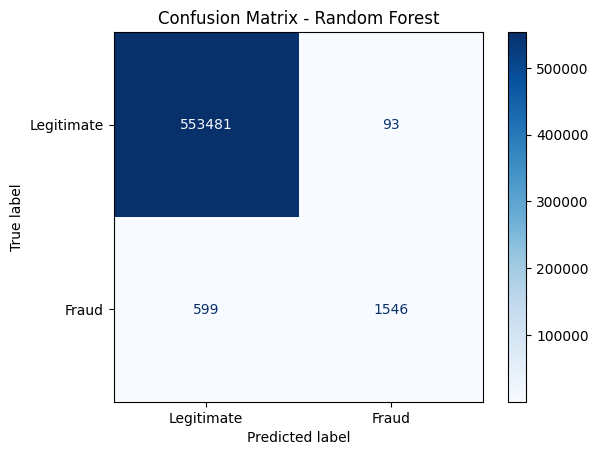

Model: XGBoost
Threshold: 0.5
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00    553574
       Fraud       0.31      0.94      0.47      2145

    accuracy                           0.99    555719
   macro avg       0.66      0.96      0.73    555719
weighted avg       1.00      0.99      0.99    555719



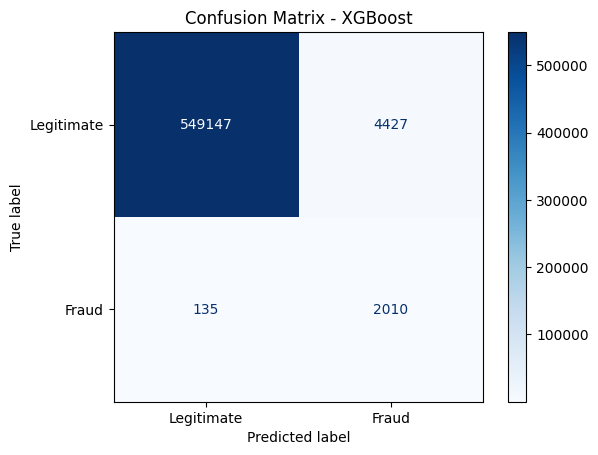

Model: LightGBM
Threshold: 0.5
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    553574
       Fraud       0.46      0.90      0.60      2145

    accuracy                           1.00    555719
   macro avg       0.73      0.95      0.80    555719
weighted avg       1.00      1.00      1.00    555719



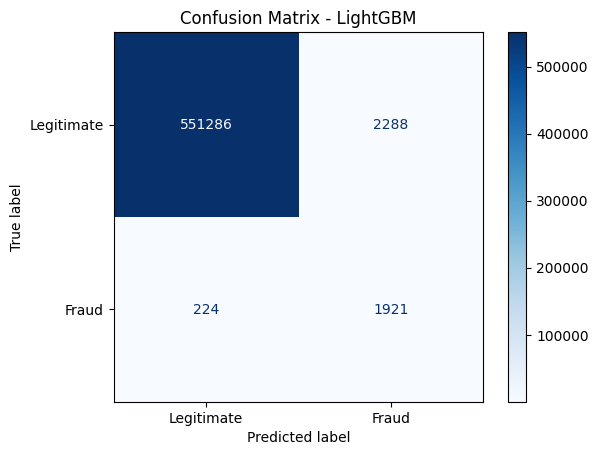

Model: CatBoost
Threshold: 0.5
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00    553574
       Fraud       0.30      0.95      0.45      2145

    accuracy                           0.99    555719
   macro avg       0.65      0.97      0.72    555719
weighted avg       1.00      0.99      0.99    555719



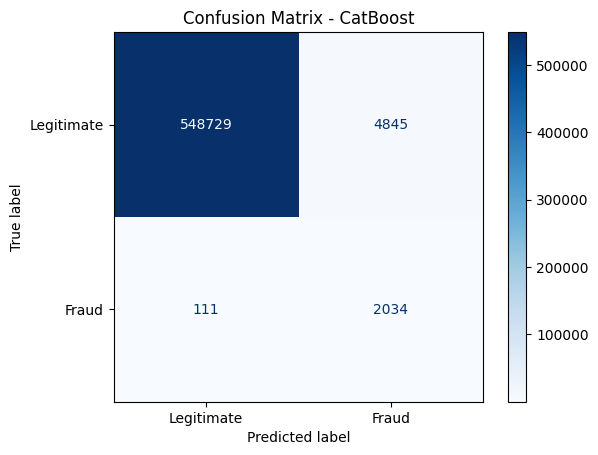

Model: Isolation Forest
Threshold: 0.0
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00    553574
       Fraud       0.05      0.07      0.06      2145

    accuracy                           0.99    555719
   macro avg       0.52      0.53      0.53    555719
weighted avg       0.99      0.99      0.99    555719



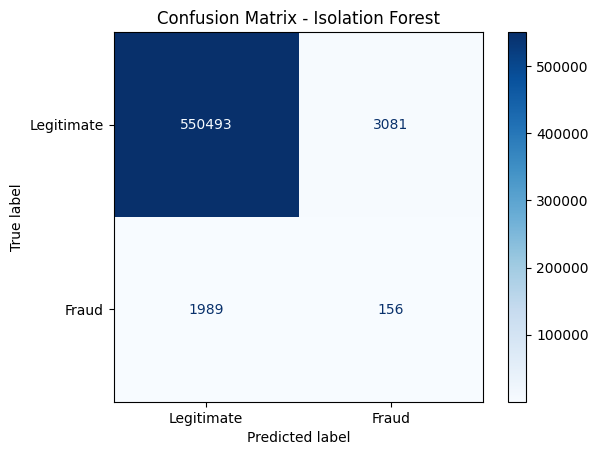

,Model,Threshold,Precision,Recall,F1,Balanced Accuracy,ROC-AUC,PR-AUC,Frauds,Predicted Frauds,TP,FP,FN,TN,False Alarm Rate
2,LightGBM,0.5,0.456403,0.895571,0.604658,0.945719,0.996655,0.871377,2145,4209,1921,2288,224,551286,0.004133
1,XGBoost,0.5,0.312257,0.937063,0.468422,0.964533,0.997078,0.871183,2145,6437,2010,4427,135,549147,0.007997
3,CatBoost,0.5,0.295683,0.948252,0.450798,0.969750,0.997062,0.869363,2145,6879,2034,4845,111,548729,0.008752
0,Random Forest,0.5,0.943258,0.720746,0.817125,0.860289,0.986724,0.867069,2145,1639,1546,93,599,553481,0.000168
4,Isolation Forest,0.0,0.048193,0.072727,0.057971,0.533581,0.807101,0.029420,2145,3237,156,3081,1989,550493,0.005566


In [ ]:
all_predictions = {}
comparison_rows = []

for model_name, model in loaded_models.items():
    print('=' * 80)
    print('Model:', model_name)
    print('=' * 80)

    y_pred, y_score, threshold = predict_with_threshold(model_name, model, X_test)
    all_predictions[model_name] = {
        'y_pred': y_pred,
        'y_score': y_score,
        'threshold': threshold,
    }

    print('Threshold:', threshold)
    print(classification_report(y_test, y_pred, target_names=LABELS, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.grid(False)
    plt.show()

    metrics = compute_metrics(y_test, y_pred, y_score)
    metrics['Model'] = model_name
    metrics['Threshold'] = threshold
    comparison_rows.append(metrics)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df[
    ['Model', 'Threshold', 'Precision', 'Recall', 'F1', 'Balanced Accuracy', 'ROC-AUC', 'PR-AUC',
     'Frauds', 'Predicted Frauds', 'TP', 'FP', 'FN', 'TN', 'False Alarm Rate']
].sort_values(by='PR-AUC', ascending=False)

comparison_df

## 9. Save One Prediction CSV with All Models

In [ ]:
predictions_df = pd.DataFrame({
    'y_true': y_test.values,
})

for model_name, pred_data in all_predictions.items():
    safe_name = model_name.lower().replace(' ', '_').replace('-', '_')
    predictions_df[f'{safe_name}_score'] = pred_data['y_score']
    predictions_df[f'{safe_name}_pred'] = pred_data['y_pred']

predictions_df.head()

,y_true,random_forest_score,random_forest_pred,xgboost_score,xgboost_pred,lightgbm_score,lightgbm_pred,catboost_score,catboost_pred,isolation_forest_score,isolation_forest_pred
0,0,0.0,0,0.000304,0,0.000360,0,0.000317,0,-0.087900,0
1,0,0.0,0,0.007654,0,0.001150,0,0.001293,0,-0.109411,0
2,0,0.0,0,0.000497,0,0.000143,0,0.000918,0,-0.129082,0
3,0,0.0,0,0.000329,0,0.000085,0,0.000151,0,-0.083067,0
4,0,0.0,0,0.001084,0,0.000460,0,0.001691,0,-0.110045,0


## 10. Compare Model Metrics with Bar Charts

<Figure size 900x400 with 0 Axes>

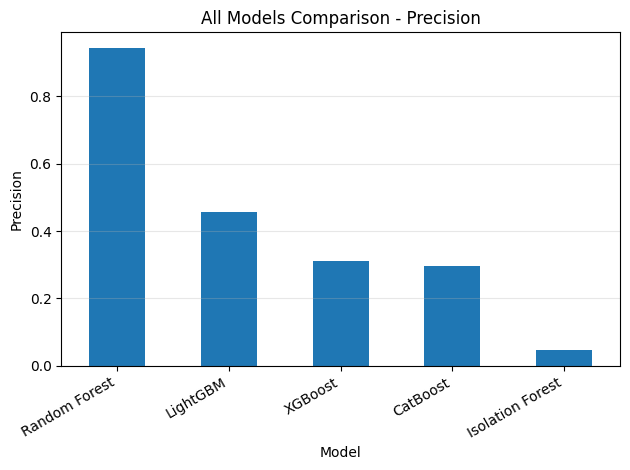

<Figure size 900x400 with 0 Axes>

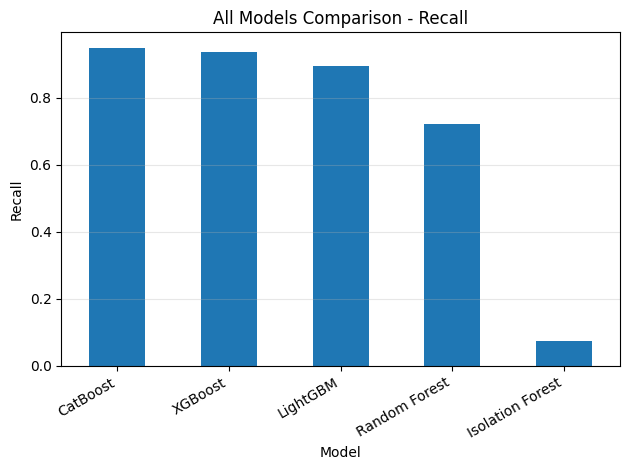

<Figure size 900x400 with 0 Axes>

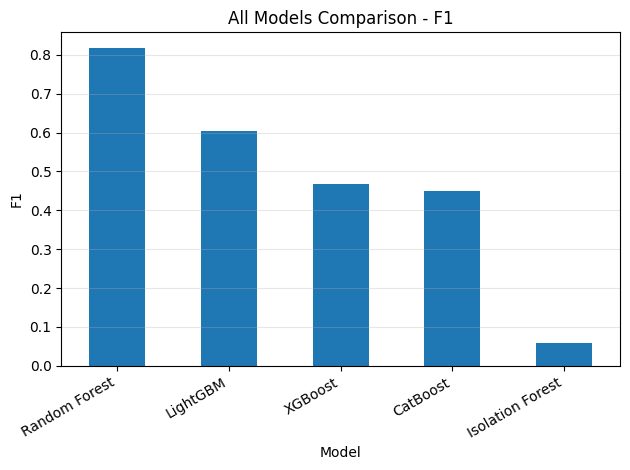

<Figure size 900x400 with 0 Axes>

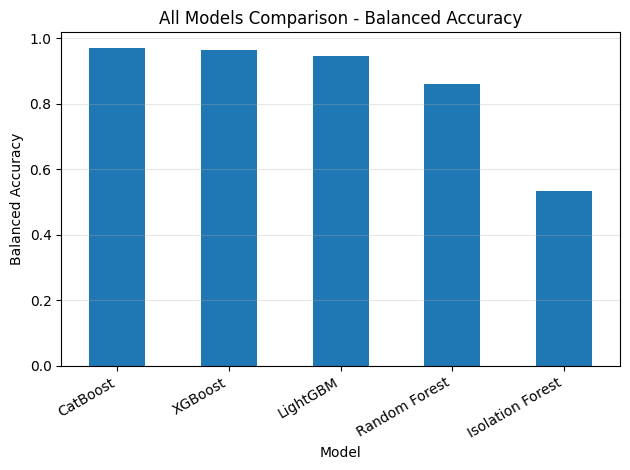

<Figure size 900x400 with 0 Axes>

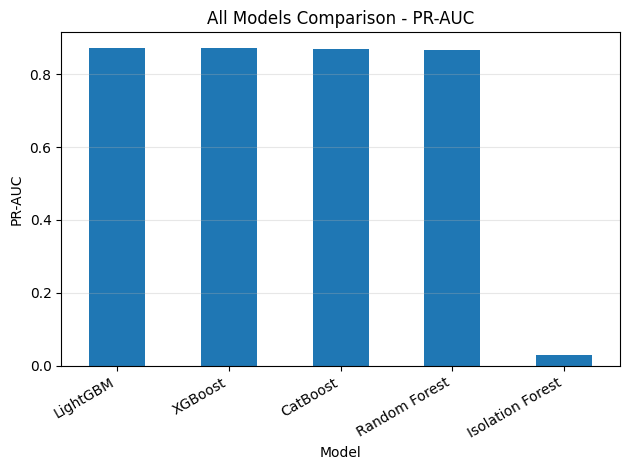

<Figure size 900x400 with 0 Axes>

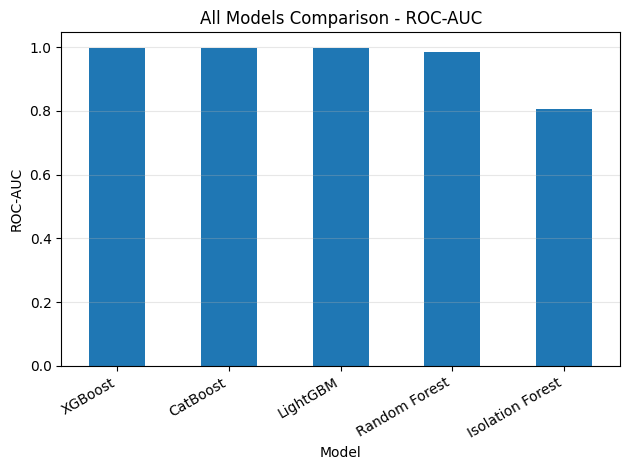

In [ ]:
metrics_to_plot = ['Precision', 'Recall', 'F1', 'Balanced Accuracy', 'PR-AUC', 'ROC-AUC']

for metric in metrics_to_plot:
    plt.figure(figsize=(9, 4))
    comparison_df.sort_values(metric, ascending=False).plot(
        x='Model', y=metric, kind='bar', legend=False
    )
    plt.title(f'All Models Comparison - {metric}')
    plt.ylabel(metric)
    plt.xticks(rotation=30, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 11. ROC and Precision-Recall Curves for All Models

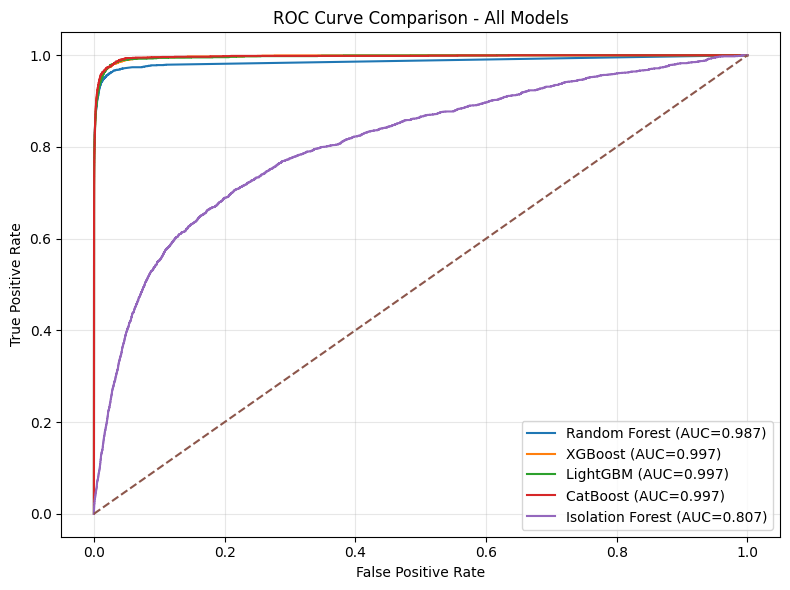

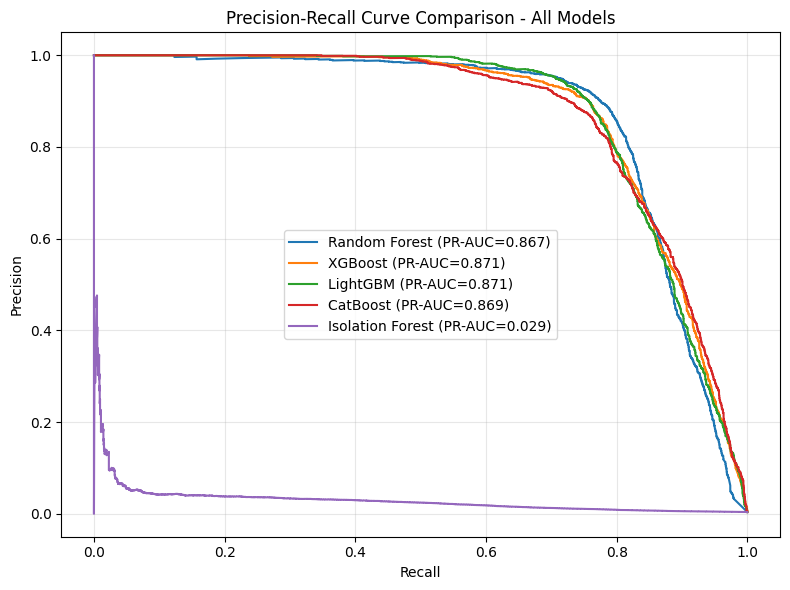

In [ ]:
plt.figure(figsize=(8, 6))
for model_name, pred_data in all_predictions.items():
    y_score = pred_data['y_score']
    try:
        fpr, tpr, _ = roc_curve(y_test, y_score)
        auc_value = roc_auc_score(y_test, y_score)
        plt.plot(fpr, tpr, label=f'{model_name} (AUC={auc_value:.3f})')
    except Exception as e:
        print('Skipping ROC for', model_name, ':', e)

plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curve Comparison - All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
for model_name, pred_data in all_predictions.items():
    y_score = pred_data['y_score']
    try:
        precision, recall, _ = precision_recall_curve(y_test, y_score)
        pr_auc = average_precision_score(y_test, y_score)
        plt.plot(recall, precision, label=f'{model_name} (PR-AUC={pr_auc:.3f})')
    except Exception as e:
        print('Skipping PR curve for', model_name, ':', e)

plt.title('Precision-Recall Curve Comparison - All Models')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Batch Evaluation for All Models

This checks if every model behaves consistently across different test batches.

In [ ]:
BATCH_SIZE = 50_000
SHUFFLE_TEST = True

if SHUFFLE_TEST:
    batch_df = test_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
else:
    batch_df = test_df.reset_index(drop=True)

batch_rows = []

for batch_id, start in enumerate(range(0, len(batch_df), BATCH_SIZE), start=1):
    end = min(start + BATCH_SIZE, len(batch_df))
    raw_batch = batch_df.iloc[start:end]
    X_batch, y_batch = preprocess_for_backend(raw_batch)

    for model_name, model in loaded_models.items():
        y_pred_batch, y_score_batch, threshold = predict_with_threshold(model_name, model, X_batch)
        metrics = compute_metrics(y_batch, y_pred_batch, y_score_batch)
        metrics['Model'] = model_name
        metrics['Threshold'] = threshold
        metrics['Batch'] = batch_id
        metrics['Start Row'] = start
        metrics['End Row'] = end
        metrics['Batch Size'] = len(raw_batch)
        batch_rows.append(metrics)

batch_results_df = pd.DataFrame(batch_rows)
batch_results_df = batch_results_df[
    ['Model', 'Batch', 'Start Row', 'End Row', 'Batch Size', 'Threshold', 'Frauds', 'Predicted Frauds',
     'Precision', 'Recall', 'F1', 'Balanced Accuracy', 'ROC-AUC', 'PR-AUC', 'TP', 'FP', 'FN', 'TN']
]

batch_results_df

,Model,Batch,Start Row,End Row,Batch Size,Threshold,Frauds,Predicted Frauds,Precision,Recall,F1,Balanced Accuracy,ROC-AUC,PR-AUC,TP,FP,FN,TN
0,Random Forest,1,0,50000,50000,0.5,195,158,0.943038,0.764103,0.844193,0.881961,0.992387,0.906527,149,9,46,49796
1,XGBoost,1,0,50000,50000,0.5,195,593,0.315346,0.958974,0.474619,0.975411,0.998855,0.907623,187,406,8,49399
2,LightGBM,1,0,50000,50000,0.5,195,404,0.448020,0.928205,0.604341,0.961864,0.998714,0.900603,181,223,14,49582
3,CatBoost,1,0,50000,50000,0.5,195,633,0.296998,0.964103,0.454106,0.977584,0.998649,0.905687,188,445,7,49360
4,Isolation Forest,1,0,50000,50000,0.0,195,282,0.031915,0.046154,0.037736,0.520336,0.831741,0.026179,9,273,186,49532
5,Random Forest,2,50000,100000,50000,0.5,192,146,0.938356,0.713542,0.810651,0.856680,0.981736,0.881041,137,9,55,49799
6,XGBoost,2,50000,100000,50000,0.5,192,583,0.317324,0.963542,0.477419,0.977775,0.996055,0.887010,185,398,7,49410
7,LightGBM,2,50000,100000,50000,0.5,192,386,0.466321,0.937500,0.622837,0.966682,0.994571,0.883915,180,206,12,49602
8,CatBoost,2,50000,100000,50000,0.5,192,629,0.295707,0.968750,0.453106,0.979928,0.994958,0.880597,186,443,6,49365
9,Isolation Forest,2,50000,100000,50000,0.0,192,284,0.045775,0.067708,0.054622,0.531134,0.821336,0.030972,13,271,179,49537


## 13. Batch Metric Plots for All Models

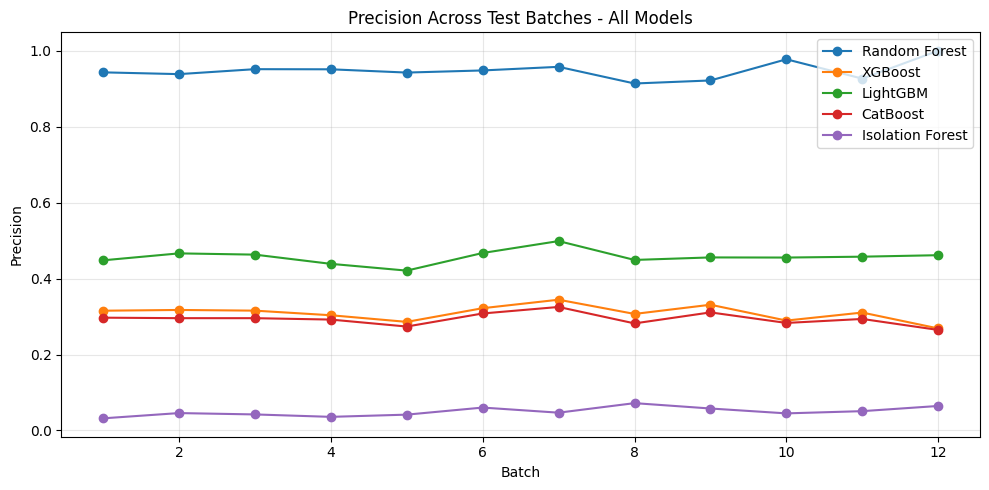

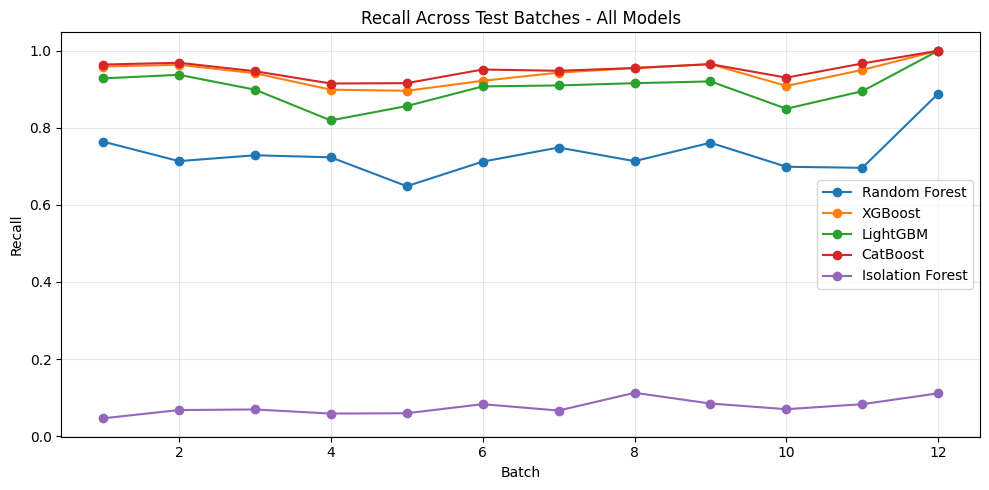

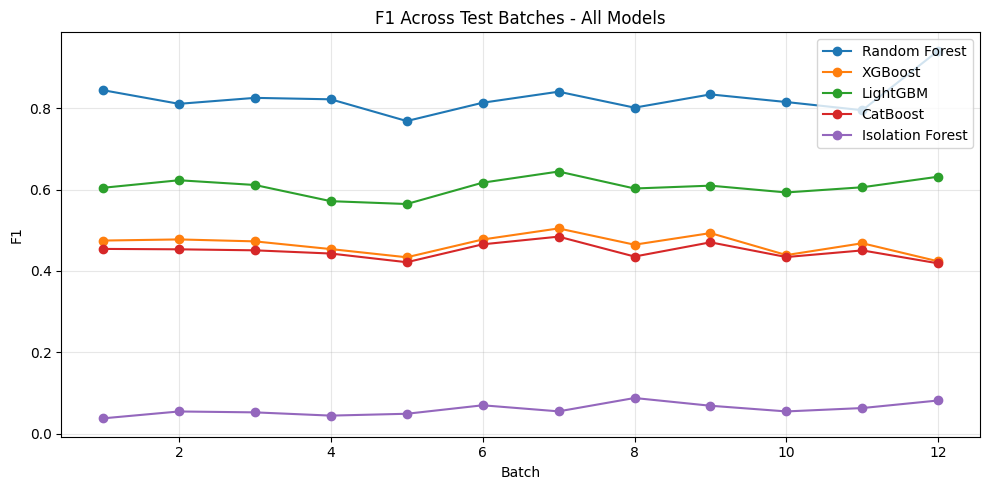

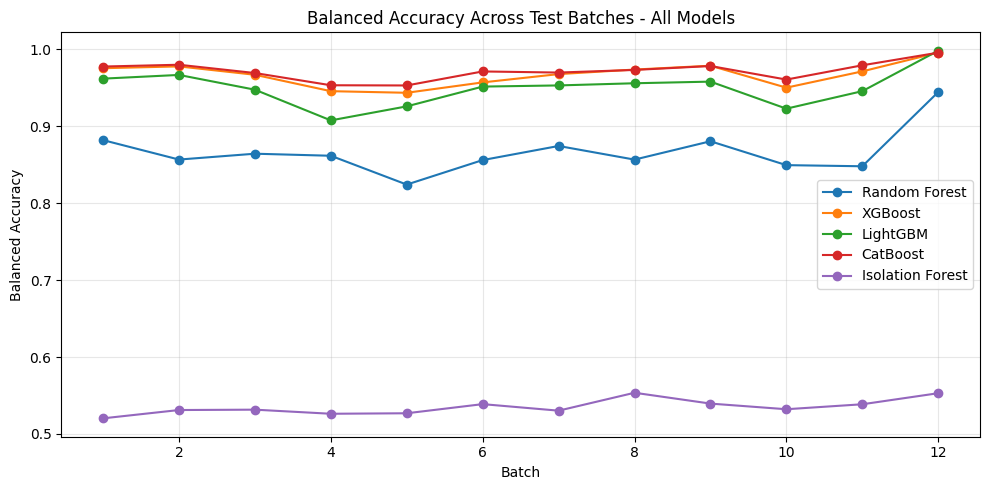

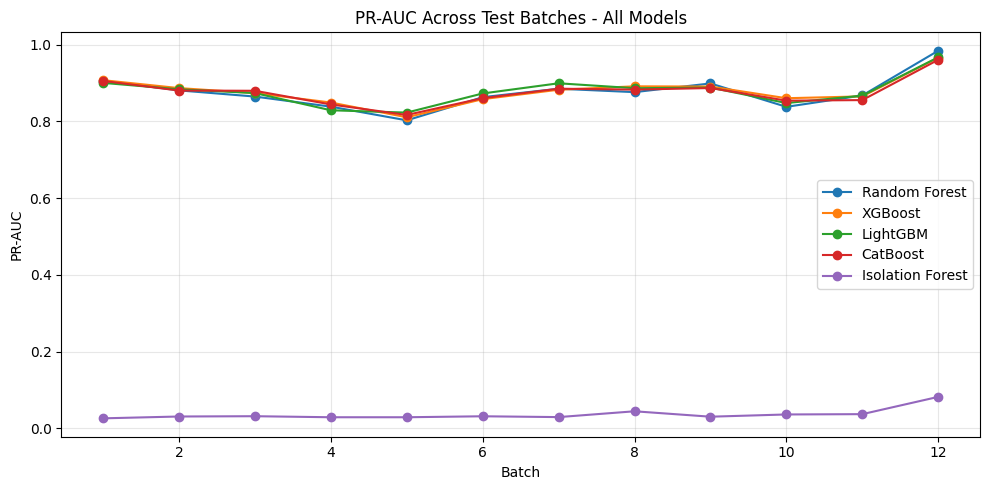

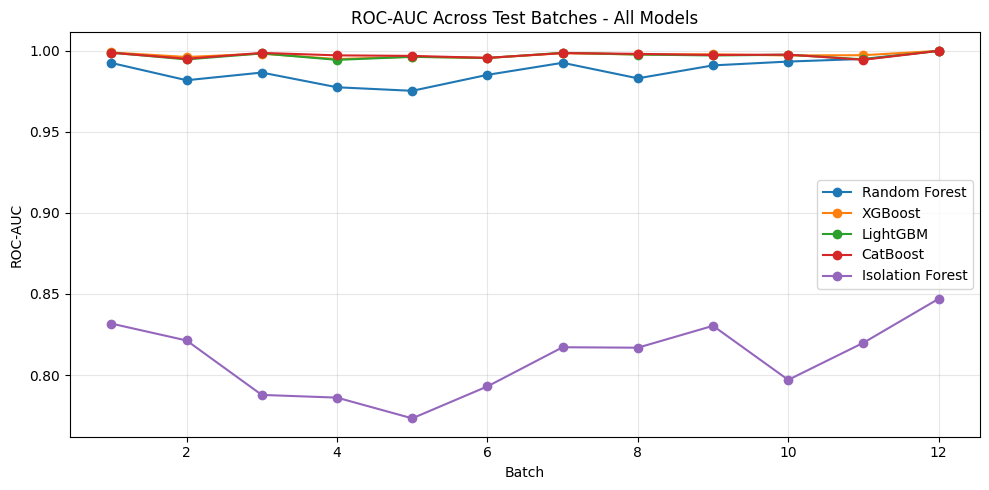

In [ ]:
metrics_to_plot = ['Precision', 'Recall', 'F1', 'Balanced Accuracy', 'PR-AUC', 'ROC-AUC']

for metric in metrics_to_plot:
    plt.figure(figsize=(10, 5))
    for model_name in batch_results_df['Model'].unique():
        model_batches = batch_results_df[batch_results_df['Model'] == model_name]
        plt.plot(model_batches['Batch'], model_batches[metric], marker='o', label=model_name)
    plt.title(f'{metric} Across Test Batches - All Models')
    plt.xlabel('Batch')
    plt.ylabel(metric)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 14. Top-K Review Test for All Models

This simulates a backend/business scenario: if only the most suspicious transactions are reviewed, which model catches more fraud?

In [ ]:
top_k_values = [100, 500, 1000, 5000, 10000]
topk_rows = []
total_frauds = int(y_test.sum())

for model_name, pred_data in all_predictions.items():
    ranked_test = pd.DataFrame({
        'y_true': y_test.values,
        'score': pred_data['y_score'],
    }).sort_values('score', ascending=False)

    for k in top_k_values:
        k = min(k, len(ranked_test))
        frauds_found = int(ranked_test.head(k)['y_true'].sum())
        topk_rows.append({
            'Model': model_name,
            'Top K Reviewed': k,
            'Frauds Found': frauds_found,
            'Total Frauds In Test': total_frauds,
            'Fraud Capture Rate': frauds_found / max(total_frauds, 1),
            'Precision@K': frauds_found / k,
        })

topk_df = pd.DataFrame(topk_rows)
topk_df.sort_values(['Top K Reviewed', 'Fraud Capture Rate'], ascending=[True, False])

,Model,Top K Reviewed,Frauds Found,Total Frauds In Test,Fraud Capture Rate,Precision@K
0,Random Forest,100,100,2145,0.046620,1.0000
5,XGBoost,100,100,2145,0.046620,1.0000
10,LightGBM,100,100,2145,0.046620,1.0000
15,CatBoost,100,100,2145,0.046620,1.0000
20,Isolation Forest,100,22,2145,0.010256,0.2200
6,XGBoost,500,500,2145,0.233100,1.0000
11,LightGBM,500,500,2145,0.233100,1.0000
16,CatBoost,500,500,2145,0.233100,1.0000
1,Random Forest,500,497,2145,0.231702,0.9940
21,Isolation Forest,500,49,2145,0.022844,0.0980


## 15. Train Sample vs Test Set Overfit Check for All Models

In [ ]:
TRAIN_SAMPLE_SIZE = 100_000
train_sample_df = train_df.sample(
    n=min(TRAIN_SAMPLE_SIZE, len(train_df)),
    random_state=RANDOM_STATE
).reset_index(drop=True)

X_train_sample, y_train_sample = preprocess_for_backend(train_sample_df)

overfit_rows = []

for model_name, model in loaded_models.items():
    y_pred_train, y_score_train, threshold = predict_with_threshold(model_name, model, X_train_sample)
    train_metrics = compute_metrics(y_train_sample, y_pred_train, y_score_train)
    train_metrics['Model'] = model_name
    train_metrics['Dataset'] = 'Train Sample'

    y_pred_test = all_predictions[model_name]['y_pred']
    y_score_test = all_predictions[model_name]['y_score']
    test_metrics = compute_metrics(y_test, y_pred_test, y_score_test)
    test_metrics['Model'] = model_name
    test_metrics['Dataset'] = 'Full Test Set'

    overfit_rows.append(train_metrics)
    overfit_rows.append(test_metrics)

overfit_df = pd.DataFrame(overfit_rows)
overfit_df = overfit_df[
    ['Model', 'Dataset', 'Precision', 'Recall', 'F1', 'Balanced Accuracy', 'ROC-AUC', 'PR-AUC',
     'Frauds', 'Predicted Frauds', 'TP', 'FP', 'FN', 'TN']
]

overfit_df

,Model,Dataset,Precision,Recall,F1,Balanced Accuracy,ROC-AUC,PR-AUC,Frauds,Predicted Frauds,TP,FP,FN,TN
0,Random Forest,Train Sample,0.993355,1.000000,0.996667,0.999980,0.999999,0.999843,598,602,598,4,0,99398
1,Random Forest,Full Test Set,0.943258,0.720746,0.817125,0.860289,0.986724,0.867069,2145,1639,1546,93,599,553481
2,XGBoost,Train Sample,0.405149,1.000000,0.576663,0.995584,0.999778,0.970996,598,1476,598,878,0,98524
3,XGBoost,Full Test Set,0.312257,0.937063,0.468422,0.964533,0.997078,0.871183,2145,6437,2010,4427,135,549147
4,LightGBM,Train Sample,0.559401,1.000000,0.717457,0.997631,0.999952,0.991823,598,1069,598,471,0,98931
5,LightGBM,Full Test Set,0.456403,0.895571,0.604658,0.945719,0.996655,0.871377,2145,4209,1921,2288,224,551286
6,CatBoost,Train Sample,0.372354,1.000000,0.542650,0.994930,0.999731,0.964798,598,1606,598,1008,0,98394
7,CatBoost,Full Test Set,0.295683,0.948252,0.450798,0.969750,0.997062,0.869363,2145,6879,2034,4845,111,548729
8,Isolation Forest,Train Sample,0.077320,0.075251,0.076271,0.534924,0.829218,0.043667,598,582,45,537,553,98865
9,Isolation Forest,Full Test Set,0.048193,0.072727,0.057971,0.533581,0.807101,0.029420,2145,3237,156,3081,1989,550493


## 16. Simple Overfit Warning for All Models

In [ ]:
warning_rows = []

for model_name in overfit_df['Model'].unique():
    model_overfit = overfit_df[overfit_df['Model'] == model_name].set_index('Dataset')

    f1_gap = model_overfit.loc['Train Sample', 'F1'] - model_overfit.loc['Full Test Set', 'F1']
    prauc_gap = model_overfit.loc['Train Sample', 'PR-AUC'] - model_overfit.loc['Full Test Set', 'PR-AUC']
    recall_gap = model_overfit.loc['Train Sample', 'Recall'] - model_overfit.loc['Full Test Set', 'Recall']

    if f1_gap > 0.10 or prauc_gap > 0.10:
        warning = 'Possible overfitting warning'
    else:
        warning = 'No strong overfitting warning'

    warning_rows.append({
        'Model': model_name,
        'Recall Gap': recall_gap,
        'F1 Gap': f1_gap,
        'PR-AUC Gap': prauc_gap,
        'Warning': warning,
    })

warning_df = pd.DataFrame(warning_rows)
warning_df

,Model,Recall Gap,F1 Gap,PR-AUC Gap,Warning
0,Random Forest,0.279254,0.179542,0.132775,Possible overfitting warning
1,XGBoost,0.062937,0.108241,0.099813,Possible overfitting warning
2,LightGBM,0.104429,0.112798,0.120446,Possible overfitting warning
3,CatBoost,0.051748,0.091852,0.095434,No strong overfitting warning
4,Isolation Forest,0.002524,0.018300,0.014247,No strong overfitting warning


## 17. Backend-Style Prediction Examples for All Models

In [ ]:
N_EXAMPLES = 10
example_transactions = test_df.sample(N_EXAMPLES, random_state=7).copy()
X_examples, y_examples = preprocess_for_backend(example_transactions)

example_output = example_transactions.copy()
example_output['true_is_fraud'] = y_examples.values

for model_name, model in loaded_models.items():
    y_pred_examples, y_score_examples, threshold = predict_with_threshold(model_name, model, X_examples)
    safe_name = model_name.lower().replace(' ', '_').replace('-', '_')
    example_output[f'{safe_name}_score'] = y_score_examples
    example_output[f'{safe_name}_pred'] = y_pred_examples

cols_to_show = [
    col for col in ['trans_date_trans_time', 'category', 'amt', 'gender', 'city', 'state', 'merchant']
    if col in example_output.columns
]
cols_to_show += ['true_is_fraud']
for model_name in loaded_models.keys():
    safe_name = model_name.lower().replace(' ', '_').replace('-', '_')
    cols_to_show += [f'{safe_name}_score', f'{safe_name}_pred']

example_output[cols_to_show]

,trans_date_trans_time,category,amt,gender,city,state,merchant,true_is_fraud,random_forest_score,random_forest_pred,xgboost_score,xgboost_pred,lightgbm_score,lightgbm_pred,catboost_score,catboost_pred,isolation_forest_score,isolation_forest_pred
128747,2020-08-04 19:48:22,health_fitness,43.83,F,Hudson,KS,"fraud_Swaniawski, Nitzsche and Welch",0,0.0,0,0.003206,0,0.000809,0,0.004808,0,-0.147009,0
243352,2020-09-17 15:43:09,health_fitness,65.84,F,Cromona,KY,fraud_Kulas Group,0,0.0,0,0.000757,0,0.000276,0,0.001534,0,-0.157354,0
191021,2020-08-27 06:13:05,shopping_pos,1.10,F,Port Saint Lucie,FL,fraud_Pouros-Haag,0,0.0,0,0.000040,0,0.000047,0,0.000002,0,-0.050586,0
270708,2020-09-29 10:39:13,misc_net,100.72,M,Lubbock,TX,"fraud_Kerluke, Kertzmann and Wiza",0,0.0,0,0.000081,0,0.000038,0,0.000020,0,-0.102775,0
369670,2020-11-11 17:13:42,shopping_net,8.03,M,Arlington,VA,fraud_Goyette Inc,0,0.0,0,0.001620,0,0.000089,0,0.000527,0,-0.120110,0
375189,2020-11-14 20:28:14,personal_care,227.95,F,Nobleboro,ME,fraud_Shanahan-Lehner,0,0.0,0,0.003676,0,0.001029,0,0.004788,0,-0.063547,0
198271,2020-08-30 09:33:54,grocery_pos,176.54,F,Tyler,TX,fraud_Kiehn-Emmerich,0,0.0,0,0.000289,0,0.000069,0,0.002522,0,-0.100321,0
95377,2020-07-24 16:34:24,shopping_net,2.27,F,Houston,TX,fraud_Kassulke PLC,0,0.0,0,0.000034,0,0.000023,0,0.000004,0,-0.030851,0
120982,2020-08-02 20:10:11,home,38.88,M,Port Costa,CA,"fraud_Cole, Hills and Jewess",0,0.0,0,0.000154,0,0.000112,0,0.000070,0,-0.060521,0
411706,2020-11-30 09:53:46,misc_net,3.26,F,Barnstable,MA,"fraud_Johnson, Runolfsdottir and Mayer",0,0.0,0,0.000256,0,0.000137,0,0.000800,0,-0.115557,0


## 18. Save All Results Locally

In [ ]:
RESULTS_DIR = '/content/fraud_all_models_test_results'
os.makedirs(RESULTS_DIR, exist_ok=True)

comparison_path = os.path.join(RESULTS_DIR, 'all_models_full_test_comparison.csv')
batch_path = os.path.join(RESULTS_DIR, 'all_models_batch_results.csv')
topk_path = os.path.join(RESULTS_DIR, 'all_models_topk_results.csv')
overfit_path = os.path.join(RESULTS_DIR, 'all_models_train_vs_test_overfit.csv')
warnings_path = os.path.join(RESULTS_DIR, 'all_models_overfit_warnings.csv')
predictions_path = os.path.join(RESULTS_DIR, 'all_models_full_test_predictions.csv')
examples_path = os.path.join(RESULTS_DIR, 'backend_style_example_predictions.csv')

comparison_df.to_csv(comparison_path, index=False)
batch_results_df.to_csv(batch_path, index=False)
topk_df.to_csv(topk_path, index=False)
overfit_df.to_csv(overfit_path, index=False)
warning_df.to_csv(warnings_path, index=False)
predictions_df.to_csv(predictions_path, index=False)
example_output[cols_to_show].to_csv(examples_path, index=False)

print('Saved:', comparison_path)
print('Saved:', batch_path)
print('Saved:', topk_path)
print('Saved:', overfit_path)
print('Saved:', warnings_path)
print('Saved:', predictions_path)
print('Saved:', examples_path)

Saved: /content/fraud_all_models_test_results/all_models_full_test_comparison.csv
Saved: /content/fraud_all_models_test_results/all_models_batch_results.csv
Saved: /content/fraud_all_models_test_results/all_models_topk_results.csv
Saved: /content/fraud_all_models_test_results/all_models_train_vs_test_overfit.csv
Saved: /content/fraud_all_models_test_results/all_models_overfit_warnings.csv
Saved: /content/fraud_all_models_test_results/all_models_full_test_predictions.csv
Saved: /content/fraud_all_models_test_results/backend_style_example_predictions.csv


##Cross Validation

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Filter out Isolation Forest as it's an unsupervised model
supervised_models = {k: v for k, v in loaded_models.items() if k != 'Isolation Forest'}

for model_name, model in supervised_models.items():

    scores = cross_val_score(
        model,
        X_train_all, # Changed to X_train_all
        y_train_all, # Changed to y_train_all
        cv=cv,
        scoring="average_precision",
        n_jobs=-1
    )

    print("="*60)
    print(model_name)
    print("PR-AUC Scores:", scores)
    print("Mean:", scores.mean())
    print("Std :", scores.std())

Random Forest
PR-AUC Scores: [0.92347759 0.91811656 0.915305   0.92145948 0.92378377]
Mean: 0.9204284793528679
Std : 0.003262301400405868
XGBoost
PR-AUC Scores: [0.93144483 0.92805118 0.92917846 0.93246438 0.93132356]
Mean: 0.930492482010804
Std : 0.0016231217609903304
LightGBM
PR-AUC Scores: [0.94316136 0.94261425 0.94300347 0.94496174 0.94631949]
Mean: 0.9440120634588289
Std : 0.0014086142637212862


##Feature Importance Comparison

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

for model_name, model in {
    "Random Forest": random_forest_model,
    "XGBoost": xgboost_model,
    "LightGBM": lightgbm_model
}.items():

    if hasattr(model, "feature_importances_"):

        importance_df = pd.DataFrame({
            "Feature": X_train.columns,
            "Importance": model.feature_importances_
        })

        importance_df = importance_df.sort_values(
            by="Importance",
            ascending=False
        )

        print("\n")
        print(model_name)
        display(importance_df.head(15))

        plt.figure(figsize=(8,5))
        plt.barh(
            importance_df.head(15)["Feature"][::-1],
            importance_df.head(15)["Importance"][::-1]
        )
        plt.title(f"Top Features - {model_name}")
        plt.show()

##Threshold Optimization

In [ ]:
thresholds = np.arange(0.05, 0.95, 0.05)

rows = []

for t in thresholds:

    preds = (results["LightGBM"]["y_prob"] >= t).astype(int)

    rows.append({
        "Threshold": t,
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds)
    })

threshold_df = pd.DataFrame(rows)

display(threshold_df)

best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print("Best Threshold:")
display(best_row)

##Train vs Test Visualization

In [ ]:
metrics = ["Recall","F1","PR-AUC"]

for metric in metrics:

    plt.figure(figsize=(6,4))

    train_vals = []
    test_vals = []

    for model in overfit_df["Model"].unique():

        train_val = overfit_df[
            (overfit_df["Model"] == model)
            &
            (overfit_df["Dataset"] == "Train Sample")
        ][metric].values[0]

        test_val = overfit_df[
            (overfit_df["Model"] == model)
            &
            (overfit_df["Dataset"] == "Full Test Set")
        ][metric].values[0]

        train_vals.append(train_val)
        test_vals.append(test_val)

    x = np.arange(len(overfit_df["Model"].unique()))

    plt.bar(x-0.2, train_vals, width=0.4, label="Train")
    plt.bar(x+0.2, test_vals, width=0.4, label="Test")

    plt.xticks(
        x,
        overfit_df["Model"].unique(),
        rotation=30
    )

    plt.title(metric)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Final Notes

This notebook checks all saved models in a deployment-like flow. It loads the model files and preprocessing artifacts from Drive, applies the exact same preprocessing to the test set, and compares model behavior on the full test set, on batches, and on Top-K suspicious transactions.

For overfitting, the most useful warning is when a model performs much better on the train sample than on the full test set, especially in F1 or PR-AUC.